# Notebook 06b — PGD Impersonation Attack

Executes the sensor-level PGD attack planned in NB06a.

For each impostor pair `(x1_A, x2_B)` in the test split, we find the **minimum L2
budget ε_min** such that a PGD attack fools the authentication model (pushes
P(different) below 0.5, i.e. the model accepts A as B).

The search proceeds in two phases:
1. **Grid sweep**: ascending pass through the ε grid from NB06a.  
   Each pair exits the sweep at the first ε where the attack succeeds.
   Pairs that never succeed (even at the 10× sentinel) are resistant.
2. **Binary search**: within the bracket `[ε_failed, ε_success]` found by the
   grid, `N_BISECT` bisection steps refine ε_min.  At the final ε_min, one
   additional PGD run measures the **actual perturbation** `‖x1_adv − x1‖₂`
   (which may be slightly below ε_min since L2 projection only clips when outside
   the ball).

## Main result

Scatter plot: **attack cost vs gait distance**:
- X-axis: sensor-space L2 difficulty per (A,B) combo (from NB06a)
- Y-axis: median actual perturbation `‖δ‖₂` over pairs in that combo
- Colour: attack success rate (ASR) per combo

The expected pattern: combos with larger gait distance between A and B require
larger perturbations or are resistant altogether.

## References

See NB06a for full reference list (Madry et al. 2018, Forestier et al. 2022,
Carlini & Wagner 2017, Huang et al. 2021).

In [1]:
%load_ext autoreload
%autoreload 2


In [ ]:
import sys
sys.path.insert(0, '..')

import logging
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path
from collections import defaultdict

import torch

from src.data.auth_dataset  import normalize_auth
from src.models.gait_cnn   import GaitCNN
from src.models.auth_model import AuthModel
from src.attacks.pgd import (
    run_pgd_sensor_batched,
    pgd_sensor_variable_eps,
    batch_psame,
)

# ── Dataset configuration ─────────────────────────────────────────────────────
import sys as _sys, json; _sys.path.insert(0, '..')
from src.utils.config_loader import dataset_dirs, dataset_files
from src.data.pairs_loader   import load_auth_pairs, load_attribution

DATASET   = 'whuGAIT'  # <<< RUNNER INJECTS THIS
DATA_ROOT  = Path('../data')
_ds_dirs   = dataset_dirs(Path('../logs'), Path('../checkpoints'), artifacts_base=Path('../artifacts'), results_base=Path('../results'), dataset=DATASET)
LOG_DIR    = _ds_dirs['logs']
ARTIFACT_DIR = _ds_dirs['artifacts']
CKPT_DIR   = _ds_dirs['checkpoints']
RESULT_DIR = _ds_dirs['results']
PATHS      = dataset_files(LOG_DIR, CKPT_DIR, artifacts_dir=ARTIFACT_DIR)
RESULT_DIR.mkdir(parents=True, exist_ok=True)

# Attack hyperparameters
K_PGD        = 20  # <<< RUNNER INJECTS THIS
BATCH_ATTACK = 512    # mini-batch size for PGD forward/backward
DEVICE       = torch.device('cpu')

# Setup file produced by NB06a
SETUP_PATH = ARTIFACT_DIR / f'06a_{DATASET}_attack_setup.npz'
CKPT_PATH  = ARTIFACT_DIR / f'06b_{DATASET}_grid_ckpt.npz'

log = logging.getLogger('nb06b')
log.setLevel(logging.DEBUG)
log.handlers.clear()
fh = logging.FileHandler(LOG_DIR / f'06b_{DATASET}_attack.log', mode='w')
fh.setFormatter(logging.Formatter('%(asctime)s  %(message)s', datefmt='%H:%M:%S'))
sh = logging.StreamHandler()
sh.setFormatter(logging.Formatter('%(message)s'))
log.addHandler(fh); log.addHandler(sh)
log.info(f'=== Notebook 06b — PGD Impersonation Attack  [{DATASET}] ===')

## Section 1 — Load Setup and Data

Everything needed is loaded from two sources:
- **NB06a output** (`06a_*_attack_setup.npz`): ε grid, combo metadata, impostor pair indices.
- **Raw test split**: normalised windows `X1_te_n`, `X2_te_n` for the impostor pairs.
  The model is evaluated on these since they were never seen during training.

In [3]:
# ── Load NB07a setup ──────────────────────────────────────────────────────────
setup      = np.load(SETUP_PATH, allow_pickle=False)
EPS_GRID   = setup['eps_grid'].astype(np.float64)
eps_target = float(setup['eps_target'])
N_BISECT   = int(setup['n_bisect'])

combo_subj_a          = setup['combo_subj_a']
combo_subj_b          = setup['combo_subj_b']
combo_n_pairs         = setup['combo_n_pairs']
combo_l2              = setup['combo_l2'].astype(np.float64)
combo_baseline_scores = setup['combo_baseline_scores']

subj_w1_diff_te = setup['subj_w1_diff_te']   # subject ID for x1 of each impostor pair
subj_w2_diff_te = setup['subj_w2_diff_te']   # subject ID for x2

N_COMBOS = len(combo_subj_a)
log.info(f'Setup loaded: {N_COMBOS} combos  |  eps_target={eps_target:.3f}  |  '
         f'grid={len(EPS_GRID)} points  |  N_BISECT={N_BISECT}')

# ── Load test split ───────────────────────────────────────────────────────────
norm_stats        = np.load(PATHS['norm_stats'])
norm_mean, norm_std = norm_stats['mean'], norm_stats['std']

X1_te, X2_te, y_te = load_auth_pairs('test',  DATA_ROOT, ARTIFACT_DIR)
X1_te_n, X2_te_n, _ = normalize_auth(X1_te, X2_te, (norm_mean, norm_std))

diff_mask_te = y_te == 1
x1_diff = X1_te_n[diff_mask_te]
x2_diff = X2_te_n[diff_mask_te]
N_PAIRS  = len(x1_diff)

X1_diff_t = torch.from_numpy(x1_diff).float()
X2_diff_t = torch.from_numpy(x2_diff).float()

log.info(f'Test impostor pairs: {N_PAIRS}')
print(f'Test impostor pairs: {N_PAIRS}  |  combos: {N_COMBOS}')

# ── Rebuild combo membership (local indices into x1_diff / x2_diff) ──────────
# Each combo (A, B) owns the subset of impostor pairs where x1 belongs to A and x2 to B.
combo_local_indices = []
for a, b in zip(combo_subj_a, combo_subj_b):
    locs = np.where((subj_w1_diff_te == a) & (subj_w2_diff_te == b))[0]
    combo_local_indices.append(locs)

# Sanity check
assert sum(len(l) for l in combo_local_indices) == N_PAIRS, 'Combo index mismatch'
print('Combo membership rebuilt OK')

# ── Load model ────────────────────────────────────────────────────────────────
_cnn_n = json.load(open(PATHS['cnn_meta']))['n_classes'] if PATHS['cnn_meta'].exists() else 98
cnn = GaitCNN(n_classes=_cnn_n)
cnn.load_state_dict(torch.load(PATHS['cnn_ckpt'], map_location='cpu'))
cnn.eval()

auth_model = AuthModel(cnn).to(DEVICE)
auth_model.load_state_dict(torch.load(CKPT_DIR / 'auth_model.pt', map_location='cpu'))
auth_model.eval()
print('Model loaded')

Setup loaded: 220 combos  |  eps_target=24.536  |  grid=15 points  |  N_BISECT=6
Test impostor pairs: 3800


Test impostor pairs: 3800  |  combos: 220
Combo membership rebuilt OK
Model loaded


## Section 2 — Grid Sweep

For each ε in the grid (ascending), run PGD on all pairs not yet solved and mark
the ones that succeed.  When a pair first succeeds at ε_k, its **bracket** is
`[ε_{k−1}, ε_k]`, the binary search in Section 3 will refine within this interval.

The sweep is batched: all currently-unsolved pairs are processed together at each
ε, so the number of PGD calls equals the number of grid points (not pairs × grid).

After each ε, the current state is saved to `logs/06b_*_grid_ckpt.npz`.
Re-running the cell resumes from the last completed ε.

In [4]:
pair_succeeded = np.zeros(N_PAIRS, dtype=bool)
pair_lo        = np.zeros(N_PAIRS, dtype=np.float32)          # lower bracket bound
pair_hi        = np.full(N_PAIRS, np.inf, dtype=np.float32)   # upper bracket bound

start_grid_idx = 0
prev_eps       = 0.0

if CKPT_PATH.exists():
    ckpt = np.load(CKPT_PATH)
    pair_succeeded[:] = ckpt['pair_succeeded']
    pair_lo[:]        = ckpt['pair_lo']
    pair_hi[:]        = ckpt['pair_hi']
    start_grid_idx    = int(ckpt['last_grid_idx']) + 1
    prev_eps          = float(ckpt['last_eps'])
    log.info(f'Resumed from checkpoint: {pair_succeeded.sum()}/{N_PAIRS} solved, '
             f'continuing from grid idx {start_grid_idx} (eps={prev_eps:.3f})')
else:
    log.info('No checkpoint found — starting grid sweep from scratch')

for grid_idx, eps in enumerate(EPS_GRID):
    if grid_idx < start_grid_idx:
        continue

    pending_mask = ~pair_succeeded
    n_pending    = int(pending_mask.sum())
    if n_pending == 0:
        log.info('All pairs solved — stopping grid sweep early')
        break

    pending_idx = np.where(pending_mask)[0]
    x1_pend     = X1_diff_t[pending_idx]
    x2_pend     = X2_diff_t[pending_idx]

    x1_adv = run_pgd_sensor_batched(
        auth_model, x1_pend, x2_pend, target_label=0,
        eps=float(eps), K=K_PGD, batch_size=BATCH_ATTACK,
    )
    scores = batch_psame(auth_model, x1_adv, x2_pend, batch_size=BATCH_ATTACK)
    # batch_psame returns P(different); attack success = P(different) < 0.5

    newly_solved_local = np.where(scores < 0.5)[0]
    newly_solved       = pending_idx[newly_solved_local]
    pair_succeeded[newly_solved] = True
    pair_lo[newly_solved]        = float(prev_eps)
    pair_hi[newly_solved]        = float(eps)

    log.info(
        f'[{grid_idx+1:2d}/{len(EPS_GRID)}] eps={eps:.4f}: '
        f'+{len(newly_solved):3d} solved | '
        f'total {pair_succeeded.sum():4d}/{N_PAIRS} | '
        f'resistant {N_PAIRS - pair_succeeded.sum():4d}'
    )

    prev_eps = float(eps)

    np.savez(
        CKPT_PATH,
        pair_succeeded=pair_succeeded,
        pair_lo=pair_lo,
        pair_hi=pair_hi,
        last_grid_idx=grid_idx,
        last_eps=prev_eps,
    )

n_solved    = int(pair_succeeded.sum())
n_resistant = N_PAIRS - n_solved
log.info(f'Grid sweep complete: solved={n_solved}, resistant={n_resistant} '
         f'({n_resistant/N_PAIRS*100:.1f}%)')
print(f'Grid sweep done: solved={n_solved}/{N_PAIRS}  resistant={n_resistant}')

Resumed from checkpoint: 3790/3800 solved, continuing from grid idx 15 (eps=245.365)
Grid sweep complete: solved=3790, resistant=10 (0.3%)


Grid sweep done: solved=3790/3800  resistant=10


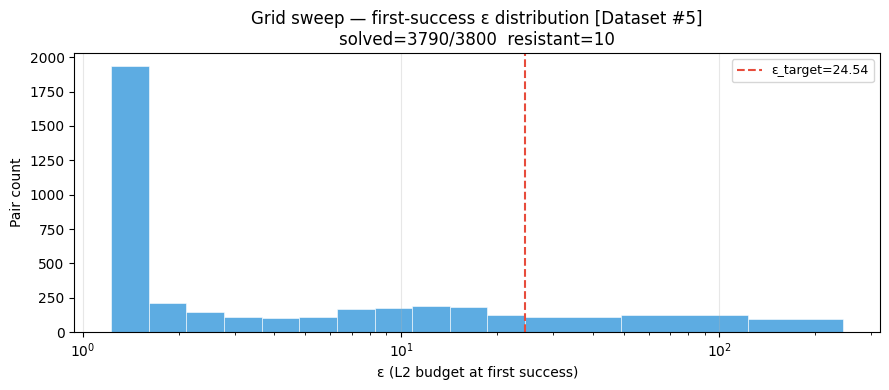

In [5]:
# Visualise first-success distribution across the grid
success_eps = pair_hi[pair_succeeded]  # ε at which each solved pair first succeeded

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(success_eps, bins=EPS_GRID, color='#3498db', alpha=0.8, edgecolor='white', linewidth=0.5)
ax.axvline(eps_target, color='#e74c3c', linewidth=1.5, linestyle='--',
           label=f'ε_target={eps_target:.2f}')
ax.set_xlabel('ε (L2 budget at first success)')
ax.set_ylabel('Pair count')
ax.set_title(f'Grid sweep — first-success ε distribution [{DATASET}]\n'
             f'solved={n_solved}/{N_PAIRS}  resistant={n_resistant}')
ax.set_xscale('log')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(RESULT_DIR / '06b_grid_sweep_hist.png', dpi=150)
plt.show()

## Section 3 — Binary Search Refinement

For each pair that found a bracket `[lo, hi]` in the grid sweep, `N_BISECT`
bisection steps narrow the interval.  At each step `mid = (lo + hi) / 2` is tested:
- success → `hi = mid` (attack works at a lower budget)
- failure  → `lo = mid`

After `N_BISECT` steps, `hi` is the refined ε_min.  All bracketed pairs are
processed simultaneously at each bisection step using `pgd_sensor_variable_eps`,
which accepts per-sample ε values, keeping the number of PGD calls to `N_BISECT + 1`
regardless of how many pairs are bracketed.

The `+1` is a final PGD run at ε_min that measures the **actual perturbation**
`‖x1_adv − x1‖₂` — the real signal change applied.

In [6]:
pair_eps_min    = np.full(N_PAIRS, np.nan, dtype=np.float32)  # ε_min per pair (NaN = resistant)
pair_actual_l2  = np.full(N_PAIRS, np.nan, dtype=np.float32)  # ‖δ‖₂ at ε_min
pair_psr        = np.full(N_PAIRS, np.nan, dtype=np.float32)  # ‖δ‖₂ / ‖x1‖₂ (signal ratio)

bracketed_idx = np.where(pair_succeeded)[0]
n_brack       = len(bracketed_idx)

log.info(f'Binary search: refining {n_brack} bracketed pairs over {N_BISECT} steps')

if n_brack > 0:
    lo_t = torch.tensor(pair_lo[bracketed_idx], dtype=torch.float32)
    hi_t = torch.tensor(pair_hi[bracketed_idx], dtype=torch.float32)
    x1_b = X1_diff_t[bracketed_idx]
    x2_b = X2_diff_t[bracketed_idx]

    for step in range(N_BISECT):
        mid = (lo_t + hi_t) / 2  # (M,) — different ε per pair

        x1_adv_mid = pgd_sensor_variable_eps(
            auth_model, x1_b, x2_b, target_label=0, eps_arr=mid, K=K_PGD
        )
        scores_mid = batch_psame(auth_model, x1_adv_mid, x2_b, batch_size=BATCH_ATTACK)
        succeeded_mid = torch.from_numpy(scores_mid) < 0.5

        hi_t = torch.where(succeeded_mid, mid, hi_t)
        lo_t = torch.where(succeeded_mid, lo_t, mid)

        log.info(
            f'  bisect {step+1}/{N_BISECT}: '
            f'mean_hi={hi_t.mean():.4f}  '
            f'mean_lo={lo_t.mean():.4f}  '
            f'gap={((hi_t - lo_t).mean()):.4f}'
        )

    pair_eps_min[bracketed_idx] = hi_t.numpy()

    # Final PGD at ε_min — measure actual perturbation and PSR
    x1_adv_final = pgd_sensor_variable_eps(
        auth_model, x1_b, x2_b, target_label=0, eps_arr=hi_t, K=K_PGD
    )
    delta_l2  = (x1_adv_final - x1_b).flatten(1).norm(dim=1)
    signal_l2 = x1_b.flatten(1).norm(dim=1).clamp(min=1e-8)

    pair_actual_l2[bracketed_idx] = delta_l2.numpy()
    pair_psr[bracketed_idx]       = (delta_l2 / signal_l2).numpy()

    mean_psr = float(np.nanmean(pair_psr))

    log.info(
        f'Binary search done: '
        f'mean_eps_min={hi_t.mean():.4f}  '
        f'mean_actual_l2={delta_l2.mean():.4f}  '
        f'mean_PSR={mean_psr:.4f}'
    )
    print(
        f'Binary search done\n'
        f'  mean ε_min              = {hi_t.mean():.4f}\n'
        f'  mean actual ‖δ‖₂        = {delta_l2.mean():.4f}\n'
        f'  mean PSR (‖δ‖/‖x‖)      = {mean_psr:.4f}  ({mean_psr*100:.2f}% of signal energy)'
    )
else:
    log.info('No bracketed pairs — all resistant')
    print('All pairs resistant')

Binary search: refining 3790 bracketed pairs over 6 steps
  bisect 1/6: mean_hi=8.3404  mean_lo=6.0850  gap=2.2554
  bisect 2/6: mean_hi=7.6566  mean_lo=6.5289  gap=1.1277
  bisect 3/6: mean_hi=7.3288  mean_lo=6.7649  gap=0.5638
  bisect 4/6: mean_hi=7.1637  mean_lo=6.8818  gap=0.2819
  bisect 5/6: mean_hi=7.0817  mean_lo=6.9407  gap=0.1410
  bisect 6/6: mean_hi=7.0412  mean_lo=6.9707  gap=0.0705
Binary search done: mean_eps_min=7.0412  mean_actual_l2=3.5775  mean_PSR=0.1323


Binary search done
  mean ε_min              = 7.0412
  mean actual ‖δ‖₂        = 3.5775
  mean PSR (‖δ‖/‖x‖)      = 0.1323  (13.23% of signal energy)


## Section 4 — Aggregate to Combo Level

Per combo `(A, B)` we aggregate the pair-level results:
- **ASR** = fraction of pairs that the attack succeeded on
- **median ε_min** = median minimum budget over successful pairs
- **median ‖δ‖₂** = median actual perturbation over successful pairs

Combos where no pair succeeded (ASR = 0) are **resistant combos**.

In [7]:
combo_asr          = np.zeros(N_COMBOS, dtype=np.float32)
combo_eps_min      = np.full(N_COMBOS, np.nan, dtype=np.float32)
combo_actual_l2    = np.full(N_COMBOS, np.nan, dtype=np.float32)
combo_psr          = np.full(N_COMBOS, np.nan, dtype=np.float32)
combo_n_solved     = np.zeros(N_COMBOS, dtype=np.int32)

for c, locs in enumerate(combo_local_indices):
    locs = np.asarray(locs)
    n_c  = len(locs)
    solved_locs = locs[pair_succeeded[locs]]
    n_solved_c  = len(solved_locs)

    combo_asr[c]      = n_solved_c / n_c
    combo_n_solved[c] = n_solved_c

    if n_solved_c > 0:
        combo_eps_min[c]   = float(np.median(pair_eps_min[solved_locs]))
        combo_actual_l2[c] = float(np.median(pair_actual_l2[solved_locs]))
        combo_psr[c]       = float(np.median(pair_psr[solved_locs]))

# ── Summary metrics across three quality axes ─────────────────────────────────
n_resistant_combos = int((combo_asr == 0).sum())
n_full_combos      = int((combo_asr == 1.0).sum())
overall_asr        = float(pair_succeeded.mean())
n_solved           = int(pair_succeeded.sum())

# Axis 1: ε_min / ε_target
mean_eps_ratio   = float(np.nanmean(pair_eps_min) / eps_target)

# Axis 2: PSR
mean_psr_global  = float(np.nanmean(pair_psr))

# Axis 3: ε_min / inter-subject L2 (per pair, using its combo's difficulty)
# Build pair_combo_l2 by writing into dataset-order indices to avoid
# combo-iteration vs dataset-order mismatch from np.concatenate.
pair_combo_l2 = np.full(N_PAIRS, np.nan, dtype=np.float32)
for c, locs in enumerate(combo_local_indices):
    pair_combo_l2[np.asarray(locs)] = combo_l2[c]
r_inter_per_pair = pair_eps_min / pair_combo_l2
mean_r_inter = float(np.nanmean(r_inter_per_pair))

log.info(
    f'Combo results: '
    f'resistant={n_resistant_combos}/{N_COMBOS}  '
    f'full_asr={n_full_combos}/{N_COMBOS}  '
    f'overall_pair_asr={overall_asr:.3f}'
)
log.info(
    f'Quality metrics: '
    f'eps_ratio={mean_eps_ratio:.4f}  '
    f'PSR={mean_psr_global:.4f} ({mean_psr_global*100:.2f}%)  '
    f'r_inter={mean_r_inter:.4f} ({mean_r_inter*100:.2f}%)'
)

print(
    f'Combo summary\n'
    f'  Total combos:          {N_COMBOS}\n'
    f'  Resistant (ASR=0):     {n_resistant_combos}  ({n_resistant_combos/N_COMBOS*100:.1f}%)\n'
    f'  Fully solved (ASR=1):  {n_full_combos}  ({n_full_combos/N_COMBOS*100:.1f}%)\n'
    f'  Overall pair ASR:      {overall_asr:.3f}\n'
    f'\nAttack quality (lower = cheaper attack)\n'
    f'  ε_min / ε_target       = {mean_eps_ratio:.4f}  ({mean_eps_ratio*100:.1f}% of natural variation budget)\n'
    f'  PSR (‖δ‖/‖x‖)          = {mean_psr_global:.4f}  ({mean_psr_global*100:.2f}% of signal energy)\n'
    f'  ε_min / inter-subj L2  = {mean_r_inter:.4f}  ({mean_r_inter*100:.2f}% of between-person distance)'
)

Combo results: resistant=0/220  full_asr=212/220  overall_pair_asr=0.997
Quality metrics: eps_ratio=0.2870  PSR=0.1323 (13.23%)  r_inter=0.1698 (16.98%)


Combo summary
  Total combos:          220
  Resistant (ASR=0):     0  (0.0%)
  Fully solved (ASR=1):  212  (96.4%)
  Overall pair ASR:      0.997

Attack quality (lower = cheaper attack)
  ε_min / ε_target       = 0.2870  (28.7% of natural variation budget)
  PSR (‖δ‖/‖x‖)          = 0.1323  (13.23% of signal energy)
  ε_min / inter-subj L2  = 0.1698  (16.98% of between-person distance)


## Section 5 — Scatter Plot: Attack Cost vs Gait Distance

Each point is one (A,B) combo:
- **X**: sensor-space L2 difficulty (mean `‖x1_A − x2_B‖₂` from NB06a)
- **Y**: median actual perturbation `‖δ‖₂` applied to fool the model
- **Colour**: ASR: how many of the combo's pairs the attack succeeded on
- **×**: resistant combos (ASR=0), plotted at a fixed Y above the range

Reference lines:
- `ε_target` (horizontal): perturbations below this are within intra-subject L2 variation
- difficulty = ε_target (vertical): only 2 combos (0.9%) are below this

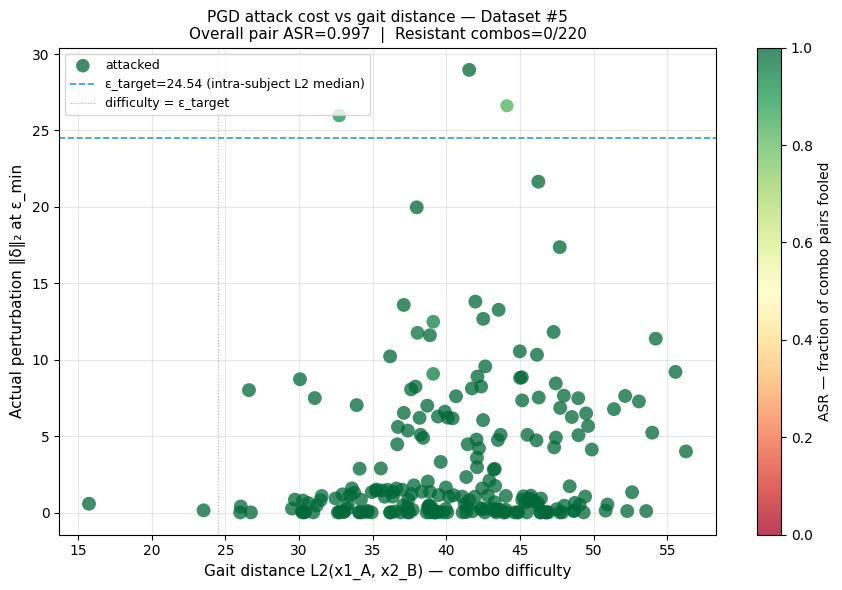

Correlation difficulty vs actual_l2: Pearson r=0.151 p=2.519e-02  Spearman ρ=0.170 p=1.164e-02


Pearson r=0.151 (p=2.519e-02)  Spearman ρ=0.170 (p=1.164e-02)


In [8]:
solved_mask    = ~np.isnan(combo_actual_l2)
resistant_mask = ~solved_mask

# Resistant combos plotted at a Y slightly above the max solved value
y_max_solved   = float(np.nanmax(combo_actual_l2)) if solved_mask.any() else eps_target
resistant_y    = y_max_solved * 1.15

fig, ax = plt.subplots(figsize=(9, 6))

cmap  = plt.cm.RdYlGn
norm  = mcolors.Normalize(vmin=0, vmax=1)

if solved_mask.any():
    sc = ax.scatter(
        combo_l2[solved_mask],
        combo_actual_l2[solved_mask],
        c=combo_asr[solved_mask], cmap=cmap, norm=norm,
        s=40 + 60 * combo_asr[solved_mask],  # larger = higher ASR
        alpha=0.75, edgecolors='none', zorder=3, label='attacked',
    )
    plt.colorbar(sc, ax=ax, label='ASR — fraction of combo pairs fooled')

if resistant_mask.any():
    ax.scatter(
        combo_l2[resistant_mask],
        np.full(resistant_mask.sum(), resistant_y),
        marker='x', color='#e74c3c', s=60, linewidths=1.5,
        zorder=4, label=f'resistant ({resistant_mask.sum()} combos)',
    )
    ax.axhline(resistant_y, color='#e74c3c', linewidth=0.5, linestyle=':', alpha=0.5)

ax.axhline(eps_target, color='#3498db', linewidth=1.2, linestyle='--',
           label=f'ε_target={eps_target:.2f} (intra-subject L2 median)')
ax.axvline(eps_target, color='gray', linewidth=0.8, linestyle=':',
           alpha=0.6, label='difficulty = ε_target')

ax.set_xlabel('Gait distance L2(x1_A, x2_B) — combo difficulty', fontsize=11)
ax.set_ylabel('Actual perturbation ‖δ‖₂ at ε_min', fontsize=11)
ax.set_title(
    f'PGD attack cost vs gait distance — {DATASET}\n'
    f'Overall pair ASR={overall_asr:.3f}  |  '
    f'Resistant combos={n_resistant_combos}/{N_COMBOS}',
    fontsize=11,
)
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(RESULT_DIR / f'06b_{DATASET}_scatter.png', dpi=150)
plt.show()

# Pearson correlation between difficulty and actual perturbation (solved only)
if solved_mask.sum() > 2:
    from scipy.stats import pearsonr, spearmanr
    r_p, p_p = pearsonr(combo_l2[solved_mask], combo_actual_l2[solved_mask])
    r_s, p_s = spearmanr(combo_l2[solved_mask], combo_actual_l2[solved_mask])
    log.info(f'Correlation difficulty vs actual_l2: Pearson r={r_p:.3f} p={p_p:.3e}  '
             f'Spearman ρ={r_s:.3f} p={p_s:.3e}')
    print(f'Pearson r={r_p:.3f} (p={p_p:.3e})  Spearman ρ={r_s:.3f} (p={p_s:.3e})')

## Section 6 — Breakdown by Difficulty Quartile

Combos are split by gait distance into four equal quartiles.  For each quartile
we report the combo-level ASR and the median actual perturbation, showing how
attack cost and success rate scale with structural similarity between subjects.

Quartile breakdown: ASR=['0.998', '0.998', '0.997', '1.000']  median_l2=['0.585', '1.372', '1.124', '1.115']


Quartile       L2 range            Combos      ASR    median ‖δ‖₂
-----------------------------------------------------------------
Q1 (easy)      15.8–36.6               55    0.998          0.585
Q2             36.6–41.2               55    0.998          1.372
Q3             41.2–45.4               55    0.997          1.124
Q4 (hard)      45.4–56.3               55    1.000          1.115


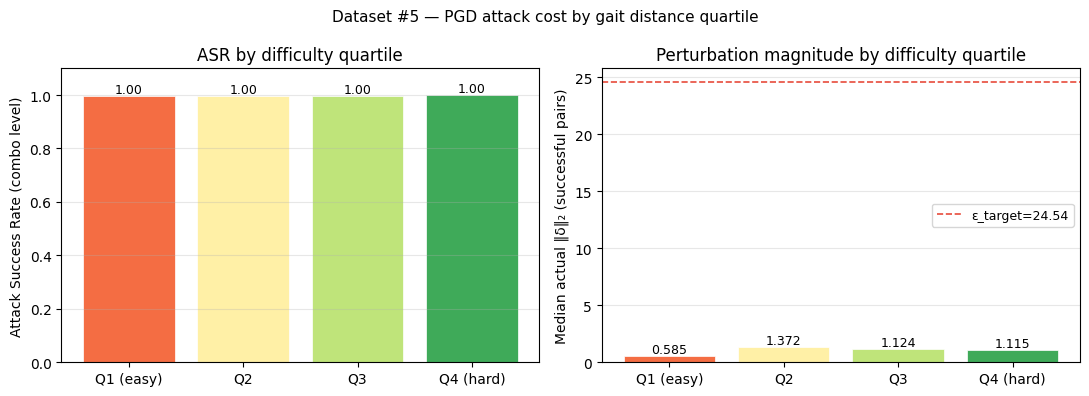

In [9]:
q_edges = np.percentile(combo_l2, [0, 25, 50, 75, 100])
q_labels = ['Q1 (easy)', 'Q2', 'Q3', 'Q4 (hard)']
q_asr, q_median_l2, q_n = [], [], []

print(f'{"Quartile":<14} {"L2 range":<18} {"Combos":>7} {"ASR":>8} {"median ‖δ‖₂":>14}')
print('-' * 65)
for i in range(4):
    mask = (combo_l2 >= q_edges[i]) & (combo_l2 < q_edges[i + 1])
    if i == 3:
        mask = (combo_l2 >= q_edges[i]) & (combo_l2 <= q_edges[i + 1])
    n_q        = mask.sum()
    asr_q      = float(combo_asr[mask].mean()) if n_q > 0 else np.nan
    med_l2_q   = float(np.nanmedian(combo_actual_l2[mask])) if n_q > 0 else np.nan
    q_asr.append(asr_q); q_median_l2.append(med_l2_q); q_n.append(int(n_q))
    l2_range = f'{q_edges[i]:.1f}–{q_edges[i+1]:.1f}'
    med_str  = f'{med_l2_q:.3f}' if not np.isnan(med_l2_q) else 'N/A'
    print(f'{q_labels[i]:<14} {l2_range:<18} {n_q:>7} {asr_q:>8.3f} {med_str:>14}')

log.info(f'Quartile breakdown: ASR={[f"{v:.3f}" for v in q_asr]}  '
         f'median_l2={[f"{v:.3f}" if not np.isnan(v) else "nan" for v in q_median_l2]}')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
colors = plt.cm.RdYlGn([0.2, 0.45, 0.65, 0.85])
bars = ax.bar(q_labels, q_asr, color=colors, edgecolor='white', linewidth=0.5)
ax.bar_label(bars, fmt='%.2f', fontsize=9)
ax.set_ylim(0, 1.1); ax.set_ylabel('Attack Success Rate (combo level)')
ax.set_title('ASR by difficulty quartile'); ax.grid(True, alpha=0.3, axis='y')

ax = axes[1]
q_med_plot = [v if not np.isnan(v) else 0.0 for v in q_median_l2]
bars2 = ax.bar(q_labels, q_med_plot, color=colors, edgecolor='white', linewidth=0.5)
ax.bar_label(bars2, fmt='%.3f', fontsize=9)
ax.axhline(eps_target, color='#e74c3c', linewidth=1.2, linestyle='--',
           label=f'ε_target={eps_target:.2f}')
ax.set_ylabel('Median actual ‖δ‖₂ (successful pairs)')
ax.set_title('Perturbation magnitude by difficulty quartile')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3, axis='y')

plt.suptitle(f'{DATASET} — PGD attack cost by gait distance quartile', fontsize=11)
plt.tight_layout()
plt.savefig(RESULT_DIR / '06b_quartile_breakdown.png', dpi=150)
plt.show()

## Section 7 — Save Results and LaTeX Metrics

In [ ]:
out_path = ARTIFACT_DIR / f'06b_{DATASET}_attack_results.npz'
np.savez(
    out_path,
    dataset_name      = DATASET,
    pair_succeeded    = pair_succeeded,
    pair_eps_min      = pair_eps_min,
    pair_actual_l2    = pair_actual_l2,
    pair_psr          = pair_psr,
    combo_asr         = combo_asr,
    combo_eps_min     = combo_eps_min,
    combo_actual_l2   = combo_actual_l2,
    combo_psr         = combo_psr,
    combo_l2          = combo_l2,
    combo_subj_a      = combo_subj_a,
    combo_subj_b      = combo_subj_b,
    eps_target        = np.float32(eps_target),
    k_pgd             = np.int32(K_PGD),
    n_bisect          = np.int32(N_BISECT),
)
print(f'Saved: {out_path}')

# Correlation values (may not exist if no solved pairs)
try:
    _r_p, _r_s = r_p, r_s
except NameError:
    _r_p = _r_s = float('nan')

log.info('=== NB06b complete ===')

## Section 8 — Attack on Training Set

The test-split attack in Sections 2–7 evaluated model fragility on **non-member pairs**:
neither A nor B is enrolled in the deployed authentication database, so the attack does
not directly map to a real impersonation threat.

The training split covers enrolled members whose reference windows are stored in the
database.  When we perturb member A's probe to be accepted as member B, we model an
insider attack: one enrolled user impersonating another.

Whether the model's familiarity with training subjects makes the attack harder
(better-calibrated boundaries) or easier (decision boundaries close to the training
manifold) is an empirical question.

When `N_COMBOS_TR_SAMPLE = None` (full training set, 33,271 pairs), this section
takes roughly 4 h on CPU. The default subsample of 500 combos (~5,000 pairs) runs
in roughly the same time as the test-split attack. A separate checkpoint file
allows resuming if interrupted.

In [ ]:
# ── Training attack configuration ─────────────────────────────────────────────
# N_COMBOS_TR_SAMPLE: randomly select this many (A,B) combos from the training
# impostor inventory.  Controls runtime — each combo takes the same time regardless
# of how many pairs it contains (all pairs in the combo are attacked).
# Set to None to use all training combos (≈4 h on CPU for Dataset #5).
N_COMBOS_TR_SAMPLE = 500  # <<< RUNNER INJECTS THIS
SEED_TR_SAMPLE     = 42  # <<< RUNNER INJECTS THIS

# ── Load training split ───────────────────────────────────────────────────────
CKPT_PATH_TR = ARTIFACT_DIR / f'06b_{DATASET}_train_grid_ckpt.npz'

X1_tr, X2_tr, y_tr = load_auth_pairs('train', DATA_ROOT, ARTIFACT_DIR)
X1_tr_n, X2_tr_n, _ = normalize_auth(X1_tr, X2_tr, (norm_mean, norm_std))

subj_w1_tr, subj_w2_tr = load_attribution('train', ARTIFACT_DIR)

diff_mask_tr = y_tr == 1
x1_diff_tr   = X1_tr_n[diff_mask_tr]
x2_diff_tr   = X2_tr_n[diff_mask_tr]

s1_tr = subj_w1_tr[diff_mask_tr]
s2_tr = subj_w2_tr[diff_mask_tr]

# ── Build full combo inventory ────────────────────────────────────────────────
combo_to_local_tr = defaultdict(list)
for loc, (a, b) in enumerate(zip(s1_tr.tolist(), s2_tr.tolist())):
    combo_to_local_tr[(int(a), int(b))].append(loc)

all_tr_combo_keys = sorted(combo_to_local_tr.keys())
N_COMBOS_TR_FULL  = len(all_tr_combo_keys)

# ── Subsample combos ──────────────────────────────────────────────────────────
if N_COMBOS_TR_SAMPLE is not None and N_COMBOS_TR_SAMPLE < N_COMBOS_TR_FULL:
    rng = np.random.default_rng(SEED_TR_SAMPLE)
    sampled_keys = sorted(
        rng.choice(all_tr_combo_keys, size=N_COMBOS_TR_SAMPLE, replace=False).tolist()
    )
else:
    sampled_keys = all_tr_combo_keys
    N_COMBOS_TR_SAMPLE = N_COMBOS_TR_FULL

tr_combo_keys = [tuple(k) for k in sampled_keys]
tr_combo_locs = [combo_to_local_tr[k] for k in tr_combo_keys]
N_COMBOS_TR   = len(tr_combo_keys)

# Gather only the local pair indices that belong to sampled combos
sampled_local_idx = np.concatenate([np.asarray(locs) for locs in tr_combo_locs])
sampled_local_idx = np.sort(sampled_local_idx)

x1_diff_tr_s = x1_diff_tr[sampled_local_idx]
x2_diff_tr_s = x2_diff_tr[sampled_local_idx]
N_PAIRS_TR   = len(sampled_local_idx)

# Remap combo local indices to the subsampled array
local_to_sub = {old: new for new, old in enumerate(sampled_local_idx.tolist())}
tr_combo_locs_sub = [
    np.array([local_to_sub[l] for l in locs]) for locs in tr_combo_locs
]

X1_diff_tr_t = torch.from_numpy(x1_diff_tr_s).float()
X2_diff_tr_t = torch.from_numpy(x2_diff_tr_s).float()

tr_combo_l2 = np.array([
    float(np.linalg.norm(
        (x1_diff_tr_s[locs] - x2_diff_tr_s[locs]).reshape(len(locs), -1), axis=1
    ).mean())
    for locs in tr_combo_locs_sub
], dtype=np.float32)

log.info(
    f'Training attack: {N_COMBOS_TR}/{N_COMBOS_TR_FULL} combos sampled  '
    f'(seed={SEED_TR_SAMPLE})  |  pairs: {N_PAIRS_TR}  |  '
    f'L2 difficulty: {tr_combo_l2.min():.2f}–{tr_combo_l2.max():.2f}'
)
print(
    f'Training combos (sampled): {N_COMBOS_TR} / {N_COMBOS_TR_FULL}\n'
    f'Training pairs:            {N_PAIRS_TR}\n'
    f'L2 difficulty:             {tr_combo_l2.min():.2f} – {tr_combo_l2.max():.2f}'
)

In [12]:
# ── Grid sweep — training split (subsampled) ──────────────────────────────────
tr_pair_succeeded = np.zeros(N_PAIRS_TR, dtype=bool)
tr_pair_lo        = np.zeros(N_PAIRS_TR, dtype=np.float32)
tr_pair_hi        = np.full(N_PAIRS_TR, np.inf, dtype=np.float32)

start_grid_idx_tr = 0
prev_eps_tr       = 0.0

if CKPT_PATH_TR.exists():
    ckpt_tr = np.load(CKPT_PATH_TR)
    # Checkpoint is valid only if it matches the current pair count
    if int(ckpt_tr.get('n_pairs', -1)) == N_PAIRS_TR:
        tr_pair_succeeded[:] = ckpt_tr['pair_succeeded']
        tr_pair_lo[:]        = ckpt_tr['pair_lo']
        tr_pair_hi[:]        = ckpt_tr['pair_hi']
        start_grid_idx_tr    = int(ckpt_tr['last_grid_idx']) + 1
        prev_eps_tr          = float(ckpt_tr['last_eps'])
        log.info(f'[train] Resumed: {tr_pair_succeeded.sum()}/{N_PAIRS_TR} solved, '
                 f'continuing from grid idx {start_grid_idx_tr}')
    else:
        log.info(f'[train] Checkpoint pair count mismatch — starting fresh '
                 f'(ckpt had {int(ckpt_tr.get("n_pairs",-1))}, current {N_PAIRS_TR})')
else:
    log.info('[train] No checkpoint — starting grid sweep from scratch')

for grid_idx, eps in enumerate(EPS_GRID):
    if grid_idx < start_grid_idx_tr:
        continue

    pending_mask = ~tr_pair_succeeded
    n_pending    = int(pending_mask.sum())
    if n_pending == 0:
        log.info('[train] All pairs solved — stopping early')
        break

    pending_idx = np.where(pending_mask)[0]
    x1_pend     = X1_diff_tr_t[pending_idx]
    x2_pend     = X2_diff_tr_t[pending_idx]

    x1_adv = run_pgd_sensor_batched(
        auth_model, x1_pend, x2_pend, target_label=0,
        eps=float(eps), K=K_PGD, batch_size=BATCH_ATTACK,
    )
    scores = batch_psame(auth_model, x1_adv, x2_pend, batch_size=BATCH_ATTACK)

    newly_solved_local = np.where(scores < 0.5)[0]
    newly_solved       = pending_idx[newly_solved_local]
    tr_pair_succeeded[newly_solved] = True
    tr_pair_lo[newly_solved]        = float(prev_eps_tr)
    tr_pair_hi[newly_solved]        = float(eps)

    log.info(
        f'[train] [{grid_idx+1:2d}/{len(EPS_GRID)}] eps={eps:.4f}: '
        f'+{len(newly_solved):4d} solved | '
        f'total {tr_pair_succeeded.sum():5d}/{N_PAIRS_TR} | '
        f'resistant {N_PAIRS_TR - tr_pair_succeeded.sum():5d}'
    )

    prev_eps_tr = float(eps)
    np.savez(
        CKPT_PATH_TR,
        pair_succeeded=tr_pair_succeeded,
        pair_lo=tr_pair_lo,
        pair_hi=tr_pair_hi,
        last_grid_idx=grid_idx,
        last_eps=prev_eps_tr,
        n_pairs=N_PAIRS_TR,           # stored so resume can detect pair-count changes
    )

tr_n_solved    = int(tr_pair_succeeded.sum())
tr_n_resistant = N_PAIRS_TR - tr_n_solved
log.info(f'[train] Grid sweep done: solved={tr_n_solved}, resistant={tr_n_resistant} '
         f'({tr_n_resistant/N_PAIRS_TR*100:.1f}%)')
print(f'[train] Grid sweep done: solved={tr_n_solved}/{N_PAIRS_TR}  resistant={tr_n_resistant}')

# ── Binary search — training split ────────────────────────────────────────────
tr_pair_eps_min   = np.full(N_PAIRS_TR, np.nan, dtype=np.float32)
tr_pair_actual_l2 = np.full(N_PAIRS_TR, np.nan, dtype=np.float32)
tr_pair_psr       = np.full(N_PAIRS_TR, np.nan, dtype=np.float32)

tr_bracketed_idx = np.where(tr_pair_succeeded)[0]
n_brack_tr       = len(tr_bracketed_idx)

log.info(f'[train] Binary search: refining {n_brack_tr} pairs over {N_BISECT} steps')

if n_brack_tr > 0:
    lo_tr  = torch.tensor(tr_pair_lo[tr_bracketed_idx], dtype=torch.float32)
    hi_tr  = torch.tensor(tr_pair_hi[tr_bracketed_idx], dtype=torch.float32)
    x1_btr = X1_diff_tr_t[tr_bracketed_idx]
    x2_btr = X2_diff_tr_t[tr_bracketed_idx]

    for step in range(N_BISECT):
        mid = (lo_tr + hi_tr) / 2
        x1_adv_mid = pgd_sensor_variable_eps(
            auth_model, x1_btr, x2_btr, target_label=0, eps_arr=mid, K=K_PGD
        )
        scores_mid    = batch_psame(auth_model, x1_adv_mid, x2_btr, batch_size=BATCH_ATTACK)
        succeeded_mid = torch.from_numpy(scores_mid) < 0.5
        hi_tr = torch.where(succeeded_mid, mid, hi_tr)
        lo_tr = torch.where(succeeded_mid, lo_tr, mid)
        log.info(f'  [train] bisect {step+1}/{N_BISECT}: mean_hi={hi_tr.mean():.4f}  '
                 f'gap={(hi_tr-lo_tr).mean():.4f}')

    tr_pair_eps_min[tr_bracketed_idx] = hi_tr.numpy()

    x1_adv_final_tr = pgd_sensor_variable_eps(
        auth_model, x1_btr, x2_btr, target_label=0, eps_arr=hi_tr, K=K_PGD
    )
    delta_l2_tr  = (x1_adv_final_tr - x1_btr).flatten(1).norm(dim=1)
    signal_l2_tr = x1_btr.flatten(1).norm(dim=1).clamp(min=1e-8)

    tr_pair_actual_l2[tr_bracketed_idx] = delta_l2_tr.numpy()
    tr_pair_psr[tr_bracketed_idx]       = (delta_l2_tr / signal_l2_tr).numpy()

    tr_mean_psr = float(np.nanmean(tr_pair_psr))
    log.info(f'[train] Binary search done: mean_eps_min={hi_tr.mean():.4f}  '
             f'mean_actual_l2={delta_l2_tr.mean():.4f}  mean_PSR={tr_mean_psr:.4f}')
    print(f'[train] mean ε_min={hi_tr.mean():.4f}  '
          f'mean ‖δ‖₂={delta_l2_tr.mean():.4f}  PSR={tr_mean_psr:.4f}')

# ── Aggregate to combo level ──────────────────────────────────────────────────
tr_combo_asr       = np.zeros(N_COMBOS_TR, dtype=np.float32)
tr_combo_eps_min   = np.full(N_COMBOS_TR, np.nan, dtype=np.float32)
tr_combo_actual_l2 = np.full(N_COMBOS_TR, np.nan, dtype=np.float32)
tr_combo_psr       = np.full(N_COMBOS_TR, np.nan, dtype=np.float32)

for c, locs in enumerate(tr_combo_locs_sub):
    locs        = np.asarray(locs)
    solved_locs = locs[tr_pair_succeeded[locs]]
    tr_combo_asr[c] = len(solved_locs) / len(locs)
    if len(solved_locs) > 0:
        tr_combo_eps_min[c]   = float(np.median(tr_pair_eps_min[solved_locs]))
        tr_combo_actual_l2[c] = float(np.median(tr_pair_actual_l2[solved_locs]))
        tr_combo_psr[c]       = float(np.median(tr_pair_psr[solved_locs]))

tr_overall_asr        = float(tr_pair_succeeded.mean())
tr_n_resistant_combos = int((tr_combo_asr == 0).sum())
tr_n_full_combos      = int((tr_combo_asr == 1.0).sum())
tr_n_solved           = tr_n_solved  # already computed above

# r_inter for training combos — fill by dataset index to avoid iteration-order mismatch
tr_pair_combo_l2 = np.full(N_PAIRS_TR, np.nan, dtype=np.float32)
for c, locs in enumerate(tr_combo_locs_sub):
    tr_pair_combo_l2[np.asarray(locs)] = tr_combo_l2[c]
tr_r_inter_per_pair = tr_pair_eps_min / tr_pair_combo_l2
tr_mean_r_inter     = float(np.nanmean(tr_r_inter_per_pair))
tr_mean_eps_ratio   = float(np.nanmean(tr_pair_eps_min) / eps_target) if tr_n_solved > 0 else float('nan')

log.info(
    f'[train] Combo results: resistant={tr_n_resistant_combos}/{N_COMBOS_TR}  '
    f'full={tr_n_full_combos}/{N_COMBOS_TR}  overall_asr={tr_overall_asr:.3f}'
)
log.info(
    f'[train] Quality: eps_ratio={tr_mean_eps_ratio:.4f}  '
    f'PSR={tr_mean_psr:.4f} ({tr_mean_psr*100:.2f}%)  '
    f'r_inter={tr_mean_r_inter:.4f} ({tr_mean_r_inter*100:.2f}%)'
)
print(
    f'\n[train] Combo summary\n'
    f'  Sampled combos:        {N_COMBOS_TR} / {N_COMBOS_TR_FULL}\n'
    f'  Resistant (ASR=0):     {tr_n_resistant_combos}  ({tr_n_resistant_combos/N_COMBOS_TR*100:.1f}%)\n'
    f'  Fully solved (ASR=1):  {tr_n_full_combos}  ({tr_n_full_combos/N_COMBOS_TR*100:.1f}%)\n'
    f'  Overall pair ASR:      {tr_overall_asr:.3f}\n'
    f'  PSR:                   {tr_mean_psr:.4f}  ({tr_mean_psr*100:.2f}% of signal energy)\n'
    f'  ε_min / inter-subj L2: {tr_mean_r_inter:.4f}  ({tr_mean_r_inter*100:.2f}%)'
)

[train] Resumed: 3499/3500 solved, continuing from grid idx 15
[train] Grid sweep done: solved=3499, resistant=1 (0.0%)
[train] Binary search: refining 3499 pairs over 6 steps


[train] Grid sweep done: solved=3499/3500  resistant=1


  [train] bisect 1/6: mean_hi=7.7284  gap=1.8004
  [train] bisect 2/6: mean_hi=7.1380  gap=0.9002
  [train] bisect 3/6: mean_hi=6.8966  gap=0.4501
  [train] bisect 4/6: mean_hi=6.7660  gap=0.2251
  [train] bisect 5/6: mean_hi=6.7028  gap=0.1125
  [train] bisect 6/6: mean_hi=6.6717  gap=0.0563
[train] Binary search done: mean_eps_min=6.6717  mean_actual_l2=4.0185  mean_PSR=0.1515
[train] Combo results: resistant=0/500  full=499/500  overall_asr=1.000
[train] Quality: eps_ratio=0.2719  PSR=0.1515 (15.15%)  r_inter=0.1667 (16.67%)


[train] mean ε_min=6.6717  mean ‖δ‖₂=4.0185  PSR=0.1515

[train] Combo summary
  Sampled combos:        500 / 4753
  Resistant (ASR=0):     0  (0.0%)
  Fully solved (ASR=1):  499  (99.8%)
  Overall pair ASR:      1.000
  PSR:                   0.1515  (15.15% of signal energy)
  ε_min / inter-subj L2: 0.1667  (16.67%)


In [ ]:
# ── Comparison: test (non-members) vs train (enrolled members, subsampled) ────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Panel 1 — ε_min distribution
ax = axes[0]
te_eps = pair_eps_min[~np.isnan(pair_eps_min)]
tr_eps = tr_pair_eps_min[~np.isnan(tr_pair_eps_min)]
if len(te_eps) > 0 and len(tr_eps) > 0:
    bins = np.geomspace(min(te_eps.min(), tr_eps.min()), EPS_GRID[-1], 40)
    ax.hist(te_eps, bins=bins, alpha=0.6, color='#3498db',
            label=f'test  (n={len(te_eps):,})', density=True)
    ax.hist(tr_eps, bins=bins, alpha=0.6, color='#e67e22',
            label=f'train (n={len(tr_eps):,})', density=True)
ax.axvline(eps_target, color='black', linewidth=1.2, linestyle='--',
           label=f'ε_target={eps_target:.2f}')
ax.set_xscale('log')
ax.set_xlabel('ε_min (L2 budget)'); ax.set_ylabel('Density')
ax.set_title(f'ε_min distribution\ntest vs train ({N_COMBOS_TR} combos sampled)')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# Panel 2 — scatter: difficulty vs actual ‖δ‖₂
ax = axes[1]
te_solved = ~np.isnan(combo_actual_l2)
tr_solved = ~np.isnan(tr_combo_actual_l2)
ax.scatter(combo_l2[te_solved],    combo_actual_l2[te_solved],
           c='#3498db', s=15, alpha=0.5, label='test (non-members)')
ax.scatter(tr_combo_l2[tr_solved], tr_combo_actual_l2[tr_solved],
           c='#e67e22', s=8,  alpha=0.4, label='train (members, sampled)')
ax.axhline(eps_target, color='black', linewidth=1, linestyle='--',
           label=f'ε_target={eps_target:.2f}')
ax.set_xlabel('Gait distance L2(x1_A, x2_B)')
ax.set_ylabel('Actual perturbation ‖δ‖₂')
ax.set_title('Attack cost vs difficulty\ntest vs train')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# Panel 3 — three quality metrics side-by-side
ax = axes[2]
metrics_lbls = ['ε_min/ε_target', 'PSR', 'ε_min/L2_inter']
te_q = [mean_eps_ratio,  mean_psr_global, mean_r_inter]
tr_q = [tr_mean_eps_ratio, tr_mean_psr,  tr_mean_r_inter]
x = np.arange(len(metrics_lbls))
w = 0.35
b1 = ax.bar(x - w/2, te_q, w, color='#3498db', alpha=0.85, label='test')
b2 = ax.bar(x + w/2, tr_q, w, color='#e67e22', alpha=0.85, label='train')
ax.bar_label(b1, fmt='%.3f', fontsize=8, padding=2)
ax.bar_label(b2, fmt='%.3f', fontsize=8, padding=2)
ax.set_xticks(x); ax.set_xticklabels(metrics_lbls, fontsize=9)
ax.set_title('Attack quality metrics\n(lower = cheaper attack)')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3, axis='y')

plt.suptitle(f'{DATASET} — PGD attack: non-members (test) vs enrolled members (train)', fontsize=11)
plt.tight_layout()
plt.savefig(RESULT_DIR / f'06b_{DATASET}_test_vs_train.png', dpi=150)
plt.show()

# ── Save training results ─────────────────────────────────────────────────────
np.savez(
    ARTIFACT_DIR / f'06b_{DATASET}_train_attack_results.npz',
    pair_succeeded    = tr_pair_succeeded,
    pair_eps_min      = tr_pair_eps_min,
    pair_actual_l2    = tr_pair_actual_l2,
    pair_psr          = tr_pair_psr,
    combo_asr         = tr_combo_asr,
    combo_eps_min     = tr_combo_eps_min,
    combo_actual_l2   = tr_combo_actual_l2,
    combo_psr         = tr_combo_psr,
    combo_l2          = tr_combo_l2,
    n_combos_full     = np.int32(N_COMBOS_TR_FULL),
    n_combos_sampled  = np.int32(N_COMBOS_TR),
    seed_tr_sample    = np.int32(SEED_TR_SAMPLE),
    eps_target        = np.float32(eps_target),
    k_pgd             = np.int32(K_PGD),
    n_bisect          = np.int32(N_BISECT),
)

print('Saved training results.')
log.info('=== NB06b Section 8 complete ===')